In [ ]:
import laspy
import numpy as np

las = laspy.read("GK_401_45.laz")

xyz = np.vstack([las.x, las.y, las.z]).T

print(las)
print("Number of points:", len(las.points))
print("Classifications:", np.unique(las.classification))
print("X range:", las.x.min(), las.x.max())
print("Y range:", las.y.min(), las.y.max())
print("Z range:", las.z.min(), las.z.max())

print("Point format:", las.point_format)
print("Dimensions:")
print(list(las.point_format.dimension_names))

<LasData(1.2, point fmt: <PointFormat(1, 0 bytes of extra dims)>, 9056221 points, 0 vlrs)>
Number of points: 9056221
Classifications: [ 1  2  3  4  5  6  7  8  9 12]
X range: 401000.0 401999.99
Y range: 45000.0 45999.99
Z range: -26.3 655.22


In [11]:
import open3d as o3d
import matplotlib.pyplot as plt

# center of tile
cx = (las.x.min() + las.x.max()) / 2
cy = (las.y.min() + las.y.max()) / 2

crop_size = 100

x, y, z = las.x, las.y, las.z
cls = np.array(las.classification)

crop_mask = (
    (x > cx - crop_size/2) & (x < cx + crop_size/2) &
    (y > cy - crop_size/2) & (y < cy + crop_size/2) &
    (~np.isin(cls, [7, 12]))
)

xyz_crop = np.vstack([x, y, z]).T[crop_mask]
cls_crop = cls[crop_mask]

print("Cropped points:", len(xyz_crop))
print("Classes:", np.unique(cls_crop, return_counts=True))

Cropped points: 59305
Classes: (array([1, 2, 3, 4, 5, 6], dtype=uint8), array([ 8443, 11193,  6100,  2392,  1740, 29437]))


Normalized range:
X: -50.488628276856616 49.49137172312476
Y: -51.3386694210858 48.641330578917405
Z: -8.390415985161432 11.729584014838569
Centroid: [ 6.91706844e-10 -2.94504092e-10  3.65555996e-14]
Scene radius: 50.0m
Camera radius: 90.0m
saved renders/side_00.png
saved renders/side_01.png
saved renders/side_02.png
saved renders/side_03.png
saved renders/side_04.png
saved renders/side_05.png
saved renders/side_06.png
saved renders/side_07.png
saved renders/top.png


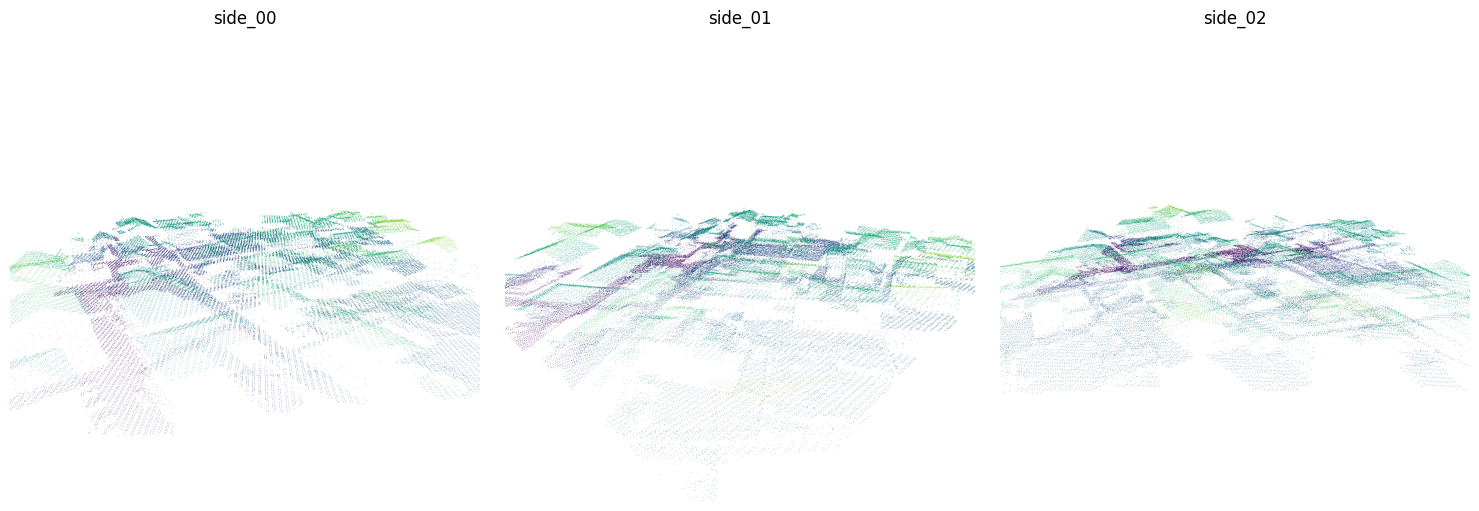

In [ ]:
from PIL import Image
import os
os.makedirs("renders", exist_ok=True)

def look_at_matrix(cam_pos, target, up=np.array([0,0,1])):
    forward = target - cam_pos
    forward = forward / np.linalg.norm(forward)
    
    right = np.cross(forward, up)
    if np.linalg.norm(right) < 1e-6:
        up = np.array([0, 1, 0])
        right = np.cross(forward, up)
    right = right / np.linalg.norm(right)
    
    up_corrected = np.cross(right, forward)
    up_corrected = up_corrected / np.linalg.norm(up_corrected)
    
    R = np.stack([right, up_corrected, forward], axis=0)
    return R

def project_points(xyz, cam_pos, R, fx=800, img_w=1024, img_h=1024):
    pts_cam = (xyz - cam_pos) @ R.T
    
    depth = pts_cam[:, 2]
    valid = depth > 0.5  # this should now work

    u = (pts_cam[:, 0] / depth * fx + img_w / 2).astype(np.float32)
    v = (-pts_cam[:, 1] / depth * fx + img_h / 2).astype(np.float32)

    valid &= (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)
    
    return u, v, depth, valid

def render_heightmap(
    xyz,
    cam_pos,
    R,
    img_w=1024,
    img_h=1024,
    fx=800,
    point_radius=2,
    background=0
):
    u, v, depth, valid = project_points(xyz, cam_pos, R, fx, img_w, img_h)

    valid_indices = np.where(valid)[0]

    u_v = u[valid].astype(np.int32)
    v_v = v[valid].astype(np.int32)
    depth_v = depth[valid]
    z_v = xyz[valid, 2]

    depth_buf = np.full((img_h, img_w), np.inf)
    height_buf = np.full((img_h, img_w), np.nan)
    point_index_image = -np.ones((img_h, img_w), dtype=np.int32)

    # nearest point should win
    order = np.argsort(depth_v)

    for j in order:
        px = u_v[j]
        py = v_v[j]

        if depth_v[j] < depth_buf[py, px]:
            depth_buf[py, px] = depth_v[j]
            height_buf[py, px] = z_v[j]
            point_index_image[py, px] = valid_indices[j]

    filled = ~np.isnan(height_buf)

    img_gray = np.full((img_h, img_w), background, dtype=np.uint8)

    if np.any(filled):
        h = height_buf[filled]
        h_min, h_max = np.percentile(h, [2, 98])

        h_norm = np.zeros((img_h, img_w), dtype=np.float32)
        h_norm[filled] = np.clip(
            (height_buf[filled] - h_min) / (h_max - h_min + 1e-6),
            0,
            1
        )

        img_gray[filled] = (h_norm[filled] * 255).astype(np.uint8)

    # make sparse LiDAR points thicker for SAM
    if point_radius > 0:
        from scipy.ndimage import maximum_filter

        img_gray = maximum_filter(img_gray, size=2 * point_radius + 1)

    img = np.stack([img_gray, img_gray, img_gray], axis=-1)

    return img, point_index_image

xyz_norm = xyz_crop.copy()
offset = xyz_crop.mean(axis=0)
xyz_norm = xyz_crop - offset

print("Normalized range:")
print("X:", xyz_norm[:,0].min(), xyz_norm[:,0].max())
print("Y:", xyz_norm[:,1].min(), xyz_norm[:,1].max())
print("Z:", xyz_norm[:,2].min(), xyz_norm[:,2].max())

centroid = xyz_norm.mean(axis=0)

scene_radius = np.max([
    xyz_norm[:, 0].max() - xyz_norm[:, 0].min(),
    xyz_norm[:, 1].max() - xyz_norm[:, 1].min()
]) / 2

cam_radius = scene_radius * 1.8
cam_height  = scene_radius * 0.6

print(f"Centroid: {centroid}")
print(f"Scene radius: {scene_radius:.1f}m")
print(f"Camera radius: {cam_radius:.1f}m")

n_side = 8
cameras = []
for i in range(n_side):
    angle = 2 * np.pi * i / n_side
    cam_pos = centroid + np.array([
        cam_radius * np.cos(angle),
        cam_radius * np.sin(angle),
        cam_height
    ])
    cameras.append((f"side_{i:02d}", cam_pos))

top_pos = centroid + np.array([0, 0, cam_radius * 1.2])
cameras.append(("top", top_pos))

# render
for name, cam_pos in cameras:
    R = look_at_matrix(cam_pos, centroid)

    img, point_index_image = render_heightmap(
        xyz_norm,
        cam_pos,
        R,
        point_radius=2,
        background=0
    )

    img_path = f"renders/{name}.png"
    idx_path = f"renders/{name}_indices.npy"

    Image.fromarray(img).save(img_path)
    np.save(idx_path, point_index_image)

    print(f"saved {img_path}")
    print(f"saved {idx_path}")